# 📊 Case NPS Preditivo

### 1. Entendimento do Negócio
O presente estudo tem por objetivo analisar os fatores que influenciam o **Net Promoter Score (NPS)**, buscando compreender o comportamento dos clientes e identificar as tendências ao longo de sua jornada de compra no *e-commerce*.

Mais do que realizar uma análise puramente descritiva, busca-se formular as perguntas certas para identificar relações e possíveis fatores associados ao **NPS**. A análise conjunta dos dados disponíveis pode revelar oportunidades de melhoria em aspectos como logística, atendimento, prazo de entrega, experiência de compra e satisfação, transformando os dados em *insights* relevantes para o negócio.

Um **NPS** elevado tende a estar associado a uma maior propensão à recompra, uma vez que clientes satisfeitos tendem a manter uma relação de lealdade com a empresa. Também pode favorecer o boca a boca, por meio de recomendações e avaliações positivas, contribuindo para a conquista de novos consumidores. No contexto do *e-commerce*, esses dois efeitos, de maior retenção e maior aquisição por recomendação, podem contribuir, no médio e longo prazos, para o crescimento das vendas e do *market share*. Essa relação, entretanto, deve ser investigada nos dados, pois **NPS** elevado não implica, por si só, causalidade sobre recompra ou participação de mercado.

Os *insights* produzidos podem ser utilizados por praticamente toda a cadeia do negócio, especialmente a de experiência do cliente. A logística pode identificar o impacto de prazos e atrasos, o atendimento pode entender o impacto da quantidade de contatos e tempo de resolução das demandas, o comercial pode mapear os fatores que aumentam a retenção e o potencial de vendas, como descontos e condições de pagamento.

A análise poderá ser mais completa se incluir aspectos de comparação com indicadores externos, permitindo contextualizar os resultados obtidos:


*   *Benchmark* de **NPS**: comparação com a média do setor e com concorrentes;
*   Concorrência: market share, crescimento, preços, frete e prazos de entrega dos principais *players*;
*   Fatores macroeconômicos, que explicam as tendências de mercado e consumo.


### 2. Definição da *Target*

A variável que representa a satisfação do cliente é o **NPS**, que consiste na nota atribuída pelo cliente à sua propensão a recomendar a empresa. O cliente atribui a nota após o encerramento da jornada de compra, e a partir dela, é classificado em **promotor** (9 a 10), **neutro** (7 a 8) ou **detrator** (abaixo de 6).

Entre os dados obtidos, o **NPS** foi escolhido por ser um indicador amplamente utilizado para avaliar a percepção, lealdade e propensão à recomendação do cliente em relação ao *e-commerce*. Para este estudo, ele permite investigar quais características da jornada de compra estão associadas a uma experiência positiva ou negativa.

O principal risco é tratar o **NPS** como uma medida absoluta de satisfação ou como uma variável que, isoladamente, explica o comportamento futuro do cliente. Um **NPS** elevado não garante, por exemplo, que haverá recompra, assim como um **NPS** baixo não significa necessariamente que o cliente deixará de comprar.






### 3. Análise Exploratória dos Dados (EDA)

In [ ]:
# Importação de bibliotecas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Leitura da base de dados
df = pd.read_csv("desafio_nps_fase_1.csv")

df.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# Verificação do tamanho da base
print(f'Tamanho do dataset: {df.shape}')

Tamanho do dataset: (2500, 19)


In [ ]:
# Verificação de nulos
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


✅ Uma vez que se verificou o tamanho da base de dados e que não há valores nulos, pode-se prosseguir com a análise.

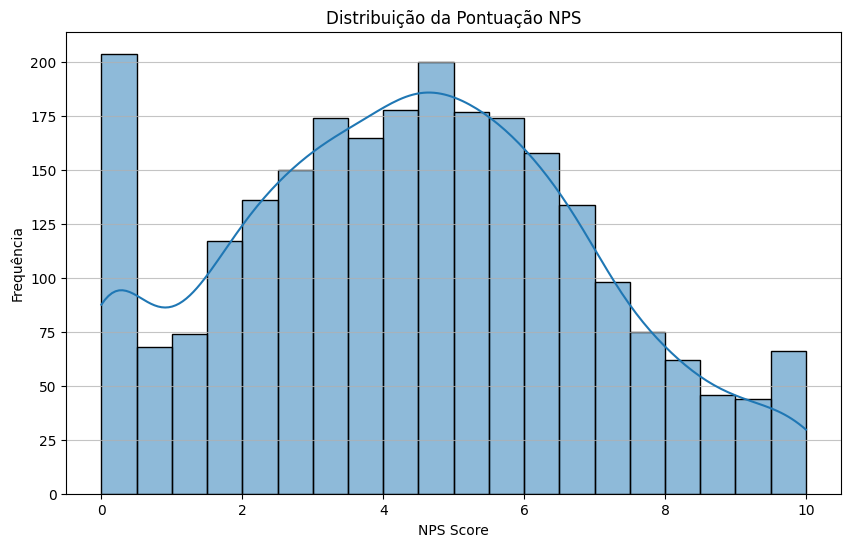

In [ ]:
# Gráfico de distribuição da pontuação do NPS
plt.figure(figsize=(10, 6))
sns.histplot(df['nps_score'], bins=20, kde=True)
plt.title('Distribuição da Pontuação NPS')
plt.xlabel('NPS Score')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Medidas estatísticas descritivas
print(df['nps_score'].describe())


count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64


In [ ]:
# Categorização do NPS entre detratores, neutros e promotores
bins = [-1, 6.99, 8.99, 11]
labels = ['Detratores', 'Neutros', 'Promotores']

df['nps_por_categoria'] = pd.cut(df['nps_score'], bins=bins, labels=labels, right=True)


display(df['nps_por_categoria'].value_counts().sort_index())

,count
nps_por_categoria,
Detratores,2109
Neutros,281
Promotores,110


In [ ]:
# Criação do gráfico com o percentual das categorias do NPS
nps_category_percentages = df['nps_por_categoria'].value_counts(normalize=True).mul(100).round(2).reset_index()
nps_category_percentages.columns = ['Categoria', 'Porcentagem']

fig = px.bar(
    nps_category_percentages,
    x='Categoria',
    y='Porcentagem',
    title='Categorias do NPS',
    labels={'Categoria': 'Categoria', 'Porcentagem': 'Porcentagem (%)'},
    color='Categoria',
    color_discrete_map={
        'Detratores': '#EF553B',
        'Neutros': '#FFBB00',
        'Promotores': '#636EFF'
    },
    text='Porcentagem'
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide', title_x=0.5)

fig.show()

A observação do gráfico de distribuição do NPS, das medidas estatísticas descritivas e da consolidação da pontuação do NPS em categorias nos permite chegar a algumas conclusões:

1. A média do NPS é 4,38, o que significa que a maior parte dos clientes são detratores.
2. A moda é a pontuação 0, indicando que há um grande número de clientes com alto grau de insatisfação.

A partir dessas afirmações, pode-se investigar quais variáveis mais contribuem para o mau resultado do NPS do *e-commerce*.

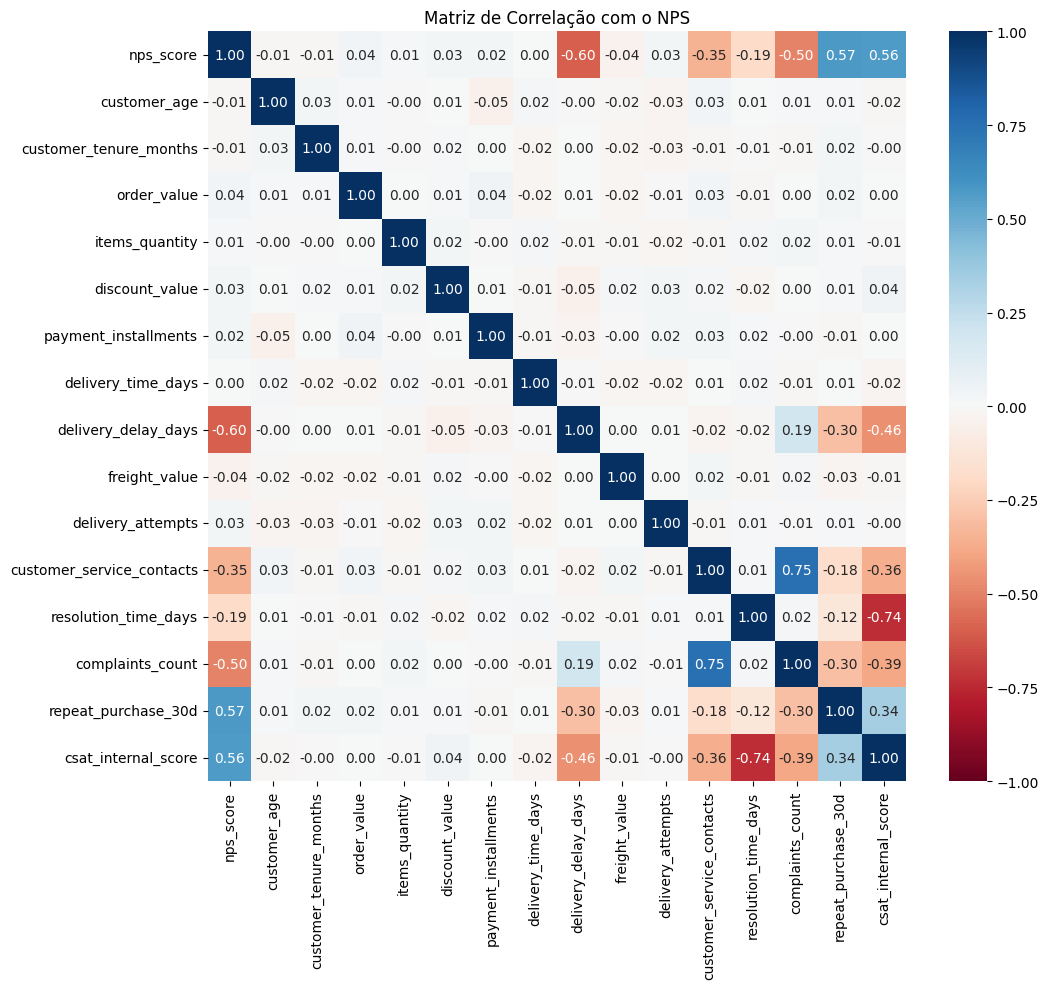

In [ ]:
# Matriz de correlação

vars_analise = ['nps_score', 'customer_age', 'customer_tenure_months', 'order_value',
                'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days',
                'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts',
                'resolution_time_days', 'complaints_count', 'repeat_purchase_30d', 'csat_internal_score'
                ]

corr = df[vars_analise].corr()

plt.figure(figsize=(11, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0,
            vmin=-1, vmax=1)
plt.title('Matriz de Correlação com o NPS')
plt.tight_layout()
plt.show()

#### **Dados Matriz de Correlação com o NPS**
O gráfico mostra quais variáveis apresentam correlação mais forte com o **NPS**.

Quanto mais próxima de 1 é a correlação, mais positiva é a relação com o **NPS**, sendo a recompra em até 30 dias e o CSAT as que apresentam essa característica.

Por outro lado, quanto mais próxima de -1, mais negativa é a relação com a pontuação de **NPS**. O tempo de atraso na entrega, o número de reclamações, número de contatos do cliente com o atendimento e o tempo para a resolução de problemas são os que demonstram maior correlação negativa.

Os valores mais próximos de 0, tanto positivos como negativos, apresentam grau de correlação mais fraco com o **NPS**.

É importante ressaltar que nem toda correlação implica causalidade, e que deve-se haver uma interpretação dos dados. No caso da análise da matriz de correlação, pode-se observar que algumas variáveis que impactaram negativamente o NPS - tempo de atraso na entrega e o tempo para a resolução de problemas - são causas para um NPS baixo.

Por outro lado, o número de reclamações, o número de contatos do cliente com o atendimento, a recompra em até 30 dias e o CSAT não são causas que influenciam o NPS, mas sim consequências que ocorrem após uma experiência, boa ou ruim.

Ou seja, o NPS não é bom porque o cliente voltou a realizar uma compra dentro de 30 dias. O NPS alto implica que o cliente teve uma jornada de sucesso, e um cliente promotor tende a comprar novamente dentro de 30 dias. Da mesma forma, o número de reclamações não é um problema em si, mas um sintoma muito claro que de existe algum problema que não foi facilmente resolvido, e que vai impactar de forma negativa o NPS.

#### **Análise dos Resultados da Matriz de Correlação**

Não existe uma correlação forte entre o tipo de cliente e o **NPS**. Fatores como idade, tempo de relacionamento com o *e-commerce* e região apresentaram valores próximos de 0, indicando não haver correlação.

Fatores relacionados ao produto e ao pagamento também não apresentaram correlação com o **NPS**. Quantidade de itens, valor do pedido, desconto e quantidade de parcelas não causaram uma influência significativa.

O frete, no entanto, parece ser um fator determinante. Por mais que o tempo previsto de entrega, o custo do frete e a quantidade de tentativas de entrega tenham pouca correlação com o **NPS**, o atraso na entrega é o que apresenta a impacto negativo mais forte.

O atendimento ao cliente é outro ponto que tem influência direta no **NPS**. O número de contatos do cliente e o número de reclamações apresentam uma correlação negativa moderada, mostrando que há algum problema que o cliente tenta solucionar pelo atendimento. O tempo para resolução do problema mostra-se uma variável com menor grau de correlação, mas que ainda tem relevância.

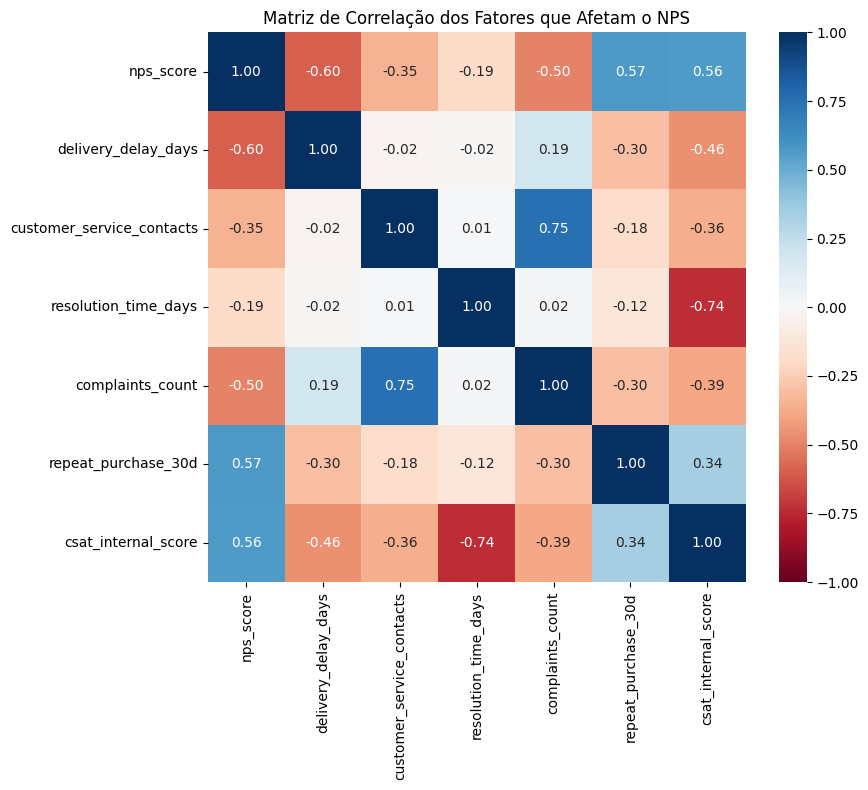

In [ ]:
# Matriz de correlação apenas com os fatores que influenciam o NPS de maneira significativa

vars_analise = ['nps_score', 'delivery_delay_days', 'customer_service_contacts',
                'resolution_time_days', 'complaints_count', 'repeat_purchase_30d', 'csat_internal_score'
                ]

corr = df[vars_analise].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0,
            vmin=-1, vmax=1)
plt.title('Matriz de Correlação dos Fatores que Afetam o NPS')
plt.tight_layout()
plt.show()

#### **Conclusão**
O entendimento a que se chega parte da hipótese de que o tempo de atraso na entrega é o principal fator que gera impacto negativo no **NPS**. O *e-commerce* deve, portanto, buscar implementar melhorias no processo de entrega, firmando parcerias com transportadoras mais confiáveis e que consigam estimar o tempo de entrega com mais precisão. A partir da reformulação dos processos de entrega dos produtos, poderão ser observadas mudanças positivas em métricas do atendimento, uma vez que existe alguma correlação entre o atraso nas entregas e o número de reclamações, e também entre o atraso nas entregas e o CSAT. Além disso, também poderão ocorrer variações positivas significativas no **NPS**.

### 4. Como a Ciência de Dados pode ser Utilizada para Antecipar a Satisfação do Cliente

A antecipação do sentimento do cliente antes da aplicação da pesquisa de **NPS** permite atuar preventivamente para a retenção de clientes, já que a pesquisa de NPS tradicional é reativa: o cliente passa por uma experiência ruim e manifesta sua insatisfação apenas após receber a pesquisa. Ao utilizar dados operacionais, comportamentais e de suporte, como tempo de atraso na entrega, número de contatos do cliente com o atendimento, quantidade de reclamações e o CSAT, a empresa consegue estimar o nível de satisfação em tempo real, logo após a entrega do pedido ou resolução do chamado.

Um modelo preditivo poderia dar suporte à empresa para estimar o NPS de maneira antecipada. Modelos de regressão preveem o valor numérico exato do **NPS** para cada operação. Neste caso, pode-se utilizar uma Random Forest.

Já os modelos de classificação podem categorizar os clientes da forma como o NPS tradicionalmente faz, ou encontrar outras formas de classificação. Poderia ser utilizada a regressão logística neste caso.

A estratégia escolhida pode ser uma abordagem que busca realizar a antecipação de risco e ação preventiva. Em vez de aguardar a resposta voluntária do cliente à pesquisa de NPS, o *e-commerce* passa a mapear os atritos operacionais no momento em que ocorrem e aplica Machine Learning para gerar um alerta preditivo.